# Implemention the nuclear recoil yield

In [ ]:
from analysis.sensitivity import scan_sensitivity
from analysis.rate_models import get_rate_ben
from analysis.dm_params import DMParams
from scipy.interpolate import interp1d
import numpy as np
import analysis.plotter as plotter
import matplotlib.pyplot as plt
import scipy.integrate as integrate


# DM model parameters
params = DMParams(m_D_GeV = 5,
                 sigma_pb = 0.1,
                 rho_GeV_cm3 = 0.3,
                 v0_kms = 230,
                 vE_kms = 250,
                 vesc_kms = 600,
                 exposure_kgdays = 11,
                 confidence_level = 0.9,
                 mass_number_A = 28,
                 c1 = 0.751, c2 = 0.561,
                 E_min_KeV= 0.63
                 )

## Nuclear Yield

In [2]:
# convert the DAMIC2025.txt file to E_nr - yield file ('DAMIC 2025.csv')
# so that all digitalized files have the same format

def convert_product_to_yield(input_file, output_file):
    # Load the original data: columns are [E_nr, E_nr * yield]
    data = np.loadtxt(input_file)
    E_nr = data[:, 0] 
    E_times_y = data[:, 1]

    # Avoid division by zero
    with np.errstate(divide='ignore', invalid='ignore'):
        yield_vals = np.where(E_nr != 0, E_times_y / E_nr, 0.0)

    # Stack into two columns and save as CSV
    converted_data = np.column_stack((E_nr * 1000, yield_vals)) # change the energy to eV unit
    np.savetxt(output_file, converted_data, delimiter=",", comments='')

    print(f"Converted data saved to {output_file}")

convert_product_to_yield("nuclear_yield/DAMIC2025.txt", "nuclear_yield/DAMIC 2025.csv")


Converted data saved to nuclear_yield/DAMIC 2025.csv


In [3]:
# def functions that convert csv file to mapping with interpolation

def lindhard(E_KeV, Z = 14):
    """ return the nuclear yield given by lindhard model (analycal)"""
    # lindhard model at k=0.146
    # input: nuclear recoil energy in KeV; atomic number of nuclear Z 
    # see also at Levin 5.1
    k = 0.146
    eta = 11.5 * E_KeV * Z ** (-7/3)
    g = 3 * eta ** 0.15 + 0.7 * eta ** 0.6 + eta
    nr_yield = k * g /(1 + k * g) # yield
    return nr_yield

    
def get_full_yield(E_KeVnr, filename = ''):
    # input = a array of recoil energy
    # read the E_vr (unit = eVnr) vs. yield files
    # interpolate in measured region
    # E > Emax; yield = lindhard
    # E < Emin: yield = 0
    # return the yield on all energy region
    if filename == '':
        return  lindhard(E_KeVnr, Z = 14)
    
    data = np.loadtxt(filename, delimiter=",")
    E_data = data[:, 0] / 1000 # convert from eV to KeV
    Y_data = data[:, 1]
    interp = interp1d(E_data, Y_data, kind='linear', bounds_error=False, fill_value="extrapolate")
    E_min, E_max = E_data[0], E_data[-1]

    E = np.atleast_1d(E_KeVnr)  # ensure array-like input
    yield_vals = np.zeros_like(E)

    in_range = (E >= E_min) & (E <= E_max)
    above_range = E > E_max

    # Interpolate where valid
    yield_vals[in_range] = interp(E[in_range])

    # Use Lindhard model above range
    yield_vals[above_range] = lindhard(E[above_range])

    # Below E_min, yield remains 0
    return yield_vals if len(yield_vals) > 1 else yield_vals[0]


In [6]:
get_full_yield(1, filename = 'nuclear_yield/DAMIC 2025.csv')

0

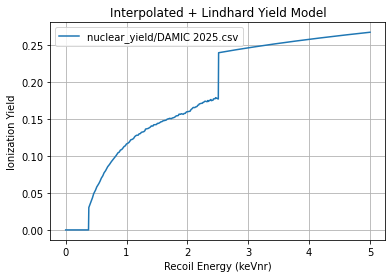

In [4]:
E_vals = np.linspace(0, 5, 1000)
# filename = 'nuclear_yield/superCDMS.csv'
# filename = 'nuclear_yield/Chavarria 2016.csv'
# filename = 'nuclear_yield/Villano 2022.csv'
filename = 'nuclear_yield/DAMIC 2025.csv'

y_vals = get_full_yield(E_vals, filename)

plt.plot(E_vals, y_vals, label = filename)
plt.xlabel("Recoil Energy (keVnr)")
plt.ylabel("Ionization Yield")
plt.title("Interpolated + Lindhard Yield Model")
plt.legend()
plt.grid()
plt.show()

### Differential Rate with the change of variables

To transform the differential rate from recoil energy \( E_{\text{nr}} \) to electron-equivalent energy \( E_{\text{ee}} \), use the chain rule:

```math
\frac{dR}{dE_{\text{ee}}} = \left. \frac{dR}{dE_{\text{nr}}} \middle/ \frac{dE_{\text{ee}}}{dE_{\text{nr}}} \right.
= \frac{dR}{dE_{\text{nr}}} \cdot \left( \frac{dE_{\text{nr}}}{dE_{\text{ee}}} \right)
```

Let the yield function be \( y(E_{\text{nr}}) \), so:

```math
E_{\text{ee}} = E_{\text{nr}} \cdot y(E_{\text{nr}})
```

Then:

```math
\frac{dE_{\text{ee}}}{dE_{\text{nr}}} = y(E_{\text{nr}}) + E_{\text{nr}} \cdot \frac{dy}{dE_{\text{nr}}}
```

Putting it together:

```math
\frac{dR}{dE_{\text{ee}}} = \frac{dR}{dE_{\text{nr}}} \cdot \left( \frac{1}{y(E_{\text{nr}}) + E_{\text{nr}} \cdot y'(E_{\text{nr}})} \right)
```


In [5]:
# Compute yield and its derivative over a global reference grid
def get_yield_and_derivative(E_ref , yield_func):
    E_ref=np.linspace(0, 5, 20)
    y_ref = yield_func(E_ref)
    y_prime_ref = np.gradient(y_ref, E_ref)
    return y_ref, y_prime_ref, E_ref

y_ref, y_prime_ref, E_ref = get_yield_and_derivative(np.linspace(0.001, 40, 5000), get_full_yield)

E_ref* y_prime_ref
print('y', y_ref)
print('y\'', y_prime_ref)
print('E_ref', E_ref)
E_ref* y_prime_ref


y [0.         0.1743783  0.19171559 0.20285149 0.21128277 0.21816753
 0.22404118 0.22919768 0.23381672 0.23801661 0.24187959 0.24546528
 0.24881834 0.25197315 0.25495677 0.25779089 0.2604932  0.26307831
 0.26555845 0.26794396]
y' [0.66263756 0.36425963 0.05409906 0.03717764 0.02910048 0.02424098
 0.02095727 0.01857352 0.01675597 0.01531946 0.01415248 0.01318362
 0.01236495 0.011663   0.0110537  0.01051922 0.01004611 0.00962399
 0.00924474 0.00906493]
E_ref [0.         0.26315789 0.52631579 0.78947368 1.05263158 1.31578947
 1.57894737 1.84210526 2.10526316 2.36842105 2.63157895 2.89473684
 3.15789474 3.42105263 3.68421053 3.94736842 4.21052632 4.47368421
 4.73684211 5.        ]


array([0.        , 0.0958578 , 0.02847319, 0.02935077, 0.03063208,
       0.03189602, 0.03309043, 0.03421438, 0.03527573, 0.03628294,
       0.03724337, 0.03816312, 0.03904721, 0.03989975, 0.04072414,
       0.04152323, 0.0422994 , 0.0430547 , 0.04379086, 0.04532465])

In [6]:


# Interpolation wrapper to evaluate derivative at arbitrary E
def get_yield_derivative(E_vals, E_ref, y_prime_ref):
    return np.interp(E_vals, E_ref, y_prime_ref)

# Main function to compute dR/dEee
def get_dR_dEee(E_KeV, dm_params, dR_dEnr_func, yield_func, E_ref, y_prime_ref):
    E_KeV = np.atleast_1d(E_KeV)

    y = yield_func(E_KeV)
    y_prime = get_yield_derivative(E_KeV, E_ref, y_prime_ref)

    dEee_dEnr = y + E_KeV * y_prime
    dEnr_dEee = 1.0 / dEee_dEnr

    dR_dEee_vals = dR_dEnr_func(E_KeV, dm_params) * dEnr_dEee

    return dR_dEee_vals if dR_dEee_vals.size > 1 else dR_dEee_vals[0]

# Wrapper that precomputes and caches the derivative once
def make_wrapped_get_dR_dEee(yield_func, dR_dEnr_func, E_ref=np.linspace(0.001, 40, 5000)):
    y_ref, y_prime_ref, E_ref = get_yield_and_derivative(E_ref, yield_func)
    
    def wrapped(E_vals, dm_params):
        return get_dR_dEee(E_vals, dm_params,
                           dR_dEnr_func=dR_dEnr_func,
                           yield_func=yield_func,
                           E_ref=E_ref,
                           y_prime_ref=y_prime_ref)
    
    return wrapped


In [7]:
wrapped_get_dR_dEee = make_wrapped_get_dR_dEee(get_full_yield, get_rate_ben)

1230.869952732418


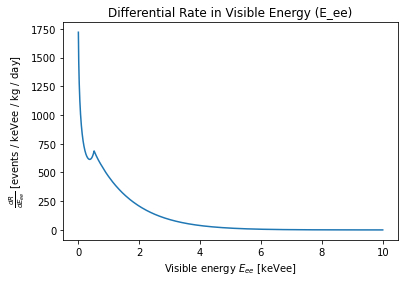

In [8]:
E_KeV = np.linspace(0.01, 10, 10000)
dRs0_ee = wrapped_get_dR_dEee(E_KeV, params)
print(np.trapz(dRs0_ee, E_KeV))

# dRs0 = [get_rate_ben(E, params) for E in E_KeV]

plt.plot(E_KeV, dRs0_ee)
plt.xlabel("Visible energy $E_{ee}$ [keVee]")
plt.ylabel(r"$\frac{dR}{dE_{ee}}$ [events / keVee / kg / day]")
plt.title("Differential Rate in Visible Energy (E_ee)")
plt.grid(False)
plt.show()

197.51055499762458


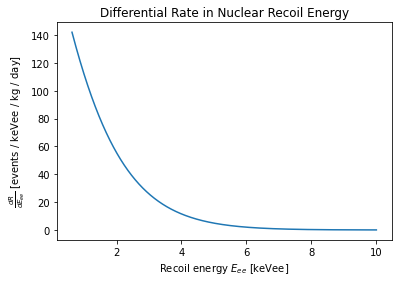

In [9]:
E_KeV = np.linspace(0.63, 10, 5000)
dRs0_nr = get_rate_ben(E_KeV = E_KeV, dm_params = params)
print(np.trapz(dRs0_nr, E_KeV))


plt.plot(E_KeV, dRs0_nr)
plt.xlabel("Recoil energy $E_{ee}$ [keVee]")
plt.ylabel(r"$\frac{dR}{dE_{ee}}$ [events / keVee / kg / day]")
plt.title("Differential Rate in Nuclear Recoil Energy")
plt.grid(False)
plt.show()

In [10]:

print(get_rate_ben(0.1, params))
wrapped_get_dR_dEee(0.3, params)

194.49284303784145


633.4961198328087

In [11]:
params = DMParams(m_D_GeV = 5,
                 sigma_pb = 0.1,
                 rho_GeV_cm3 = 0.3,
                 v0_kms = 230,
                 vE_kms = 250,
                 vesc_kms = 600,
                 exposure_kgdays = 11,
                 confidence_level = 0.9,
                 mass_number_A = 28,
                 c1 = 0.751, c2 = 0.561,
                 E_min_KeV= 0.63
                 )

In [12]:
# params.E_min_KeV= 1 # update the threshhold
print(R_tot = integrate.quad(lambda E: wrapped_get_dR_dEee(E, dm_params = params), 0.001, 6)[0])

# R_tot * params.exposure_kgdays
print(integrate.quad(lambda E: get_rate_ben(E, dm_params = params), 0.063, 6)[0])

# -np.log(1-0.9)

/var/folders/sq/dzt70hvd6_nbf2dv3q6ycsp40000gn/T/ipykernel_50319/481348431.py:2: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  print(R_tot = integrate.quad(lambda E: wrapped_get_dR_dEee(E, dm_params = params), 0.001, 6)[0])


TypeError: 'R_tot' is an invalid keyword argument for print()

In [ ]:
params.E_min_KeV= 0.005 # update the threshhold
scan_sensitivity(params, wrapped_get_dR_dEee, lgmass_range = [0.5, 1], lgxs_range = [-3, 1], npoints=100)

Scanning m_D: 100%|██████████| 100/100 [05:49<00:00,  3.49s/mass]


(array([], dtype=float64), array([], dtype=float64))

In [ ]:
wrapped_get_dR_dEee(0.05, params)

TypeError: 'float' object is not iterable

In [ ]:
# Conversion to the differential rate of Vee, plot

In [ ]:
# apply the sensitivity scan